<div style="background-image: linear-gradient(to right, #2e5a88, #1e1e1e); color: white; padding: 12px 25px; border-radius: 10px; margin-top: 25px; margin-bottom: 15px;">
    <h1 style="color: white; margin: 0; font-size: 2.0em; font-family: 'Consolas', monospace;">
        H3 · Residual Consumption &amp; Passive Efficiency (NILM)
    </h1>
    <p style="color: #d1d1d1; margin: 5px 0 0 0; font-size: 1.1em;">Residential Power Consumption Audit · Sceaux Dataset</p>
    <p style="color: #aaaaaa; margin: 4px 0 0 0; font-size: 0.95em;">Aitor — Industrial Electrical Engineer &amp; Data Engineer</p>
</div>


* **Hipótesis:**  El ratio de consumo base (Standby) frente al consumo nominal es superior al 15% durante los periodos de inactividad o descanso (madrugadas y días no laborables), indicando una ineficiencia en las cargas permanentes.
* **Objetivo:** Cuantificar el impacto económico de las cargas fantasma y sistemas auxiliares (seguridad, recirculación, domótica y modos standby) mediante la comparativa de perfiles de carga entre días laborables y fines de semana.
* **Valor de Negocio:** Identificar si el consumo base es una constante estructural o una ineficiencia operativa. El procesamiento distribuido de Spark nos permitirá segmentar grandes volúmenes de datos temporales para proponer protocolos de "apagado inteligente" o mejoras en el aislamiento eléctrico de circuitos no críticos, reduciendo el gasto energético pasivo de la vivienda.
* **Resultado:** El análisis NILM sobre el circuito «Otros» identifica una unidad de refrigeración secundaria obsoleta cuya sustitución por tecnología Inverter genera **~1.068 kWh/año de ahorro con ROI de 1,9 años**.

---
## 1. Inicialización de sesión — carga desde Parquet

In [27]:
import sys
import os
import warnings

warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

from utils.spark_session import get_spark, resolve_project_root

spark = get_spark(app_name="H3_NILM_Standby")
PROJECT_ROOT = resolve_project_root()

parquet_path = os.path.join(PROJECT_ROOT, "data_storage", "work", "power_data.parquet")
df_final = spark.read.parquet(parquet_path)
df_final.createOrReplaceTempView("power_data")

print(f"✅ Dataset cargado desde Parquet: {df_final.count():,} registros")

-------------------------------------------------------
⚡ SPARK ENGINE READY  |  app: H3_NILM_Standby
   Driver : 16g
   Executor: 8g
   Log level: ERROR
-------------------------------------------------------
✅ Dataset cargado desde Parquet: 2,049,280 registros


---
## 2. Resolución de hipótesis
### H3.1 — Eficiencia operativa: periodos activos vs. standby

In [28]:
# ==============================================================================
# H3.1: ANÁLISIS DE EFICIENCIA Y CARGA BASE (STANDBY vs. ACTIVE)
# ==============================================================================
import time

start_h3 = time.time()

query = """
SELECT 
    ROUND(AVG(CASE WHEN hour BETWEEN 6 AND 23 OR hour = 0 THEN Global_active_power END), 3) AS AVG_DAY_ACTIVE_KW,
    ROUND(AVG(CASE WHEN hour BETWEEN 1 AND 5 THEN Global_active_power END), 3) AS AVG_NIGHT_STANDBY_KW,
    ROUND(
        (AVG(CASE WHEN hour BETWEEN 1 AND 5 THEN Global_active_power END) / 
         AVG(CASE WHEN hour BETWEEN 6 AND 23 OR hour = 0 THEN Global_active_power END)) * 100, 2
    ) AS STANDBY_RATIO_PERCENT,
    ROUND(AVG(CASE WHEN is_weekend IS FALSE THEN Global_active_power END), 3) AS AVG_WEEKDAY_KW,
    ROUND(AVG(CASE WHEN is_weekend IS TRUE THEN Global_active_power END), 3) AS AVG_WEEKEND_KW,
    ROUND(
        ((AVG(CASE WHEN is_weekend IS TRUE THEN Global_active_power END) - 
          AVG(CASE WHEN is_weekend IS FALSE THEN Global_active_power END)) / 
         AVG(CASE WHEN is_weekend IS FALSE THEN Global_active_power END)) * 100, 2
    ) AS WEEKEND_INC_PERCENT
FROM power_data;
"""

periodos_de_consumo = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("📊 INFORME DE EFICIENCIA OPERATIVA (H3.1)")
print(f"⏱️ Procesado en: {time.time() - start_h3:.2f} s")
print("-" * 55)
display(periodos_de_consumo)

-------------------------------------------------------
📊 INFORME DE EFICIENCIA OPERATIVA (H3.1)
⏱️ Procesado en: 0.11 s
-------------------------------------------------------


,AVG_DAY_ACTIVE_KW,AVG_NIGHT_STANDBY_KW,STANDBY_RATIO_PERCENT,AVG_WEEKDAY_KW,AVG_WEEKEND_KW,WEEKEND_INC_PERCENT
0,1.255,0.472,37.66,1.035,1.234,19.2


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.1:**
*  AVG_DAY_ACTIVE (1.255 kW): La línea base de actividad normal.
*  AVG_NIGHT_STANDBY (0.472 kW): "Gasto fantasma". Para una vivienda, tener medio kilovatio encendido de forma constante toda la noche es el equivalente a tener 50 bombillas LED de 10W o un frigorífico industrial funcionando sin parar.
*  STANDBY_RATIO_PERCENT (37.66%): Casi el 40% de la energía se consume cuando no hay actividad. Indica que la vivienda mantiene una carga activa muy elevada durante la madrugada.
*  WEEKEND_INC_PERCENT: Durante los fines de semana, el consumo medio se incrementa un 19.23% respecto a los días laborables, lo que sugiere una oportunidad de optimización en los hábitos de consumo y programación de equipos térmicos.
</div>

---
### H3.2 — Desglose del consumo nocturno en standby

In [29]:
# ==============================================================================
# H3.2: AUDITORÍA DE CONSUMO INVISIBLE (NIGHT STANDBY ANALYSIS)
# ==============================================================================
import time

start_h3 = time.time()

query = """
SELECT 
    'MADRUGADA (01-06h)' AS periodo,
    ROUND(AVG(Global_active_power), 3) as avg_kw_total,
    ROUND(AVG(Sub_metering_1 * 0.06), 3) as avg_cocina_kw,
    ROUND(AVG(Sub_metering_2 * 0.06), 3) as avg_lavadero_kw,
    ROUND(AVG(Sub_metering_3 * 0.06), 3) as avg_clima_kw,
    ROUND(
        AVG(Global_active_power) - 
        AVG((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06), 
    3) as avg_otros_kw,
    ROUND((AVG(Sub_metering_1 * 0.06) / AVG(Global_active_power)) * 100, 2) as pct_cocina,
    ROUND((AVG(Sub_metering_2 * 0.06) / AVG(Global_active_power)) * 100, 2) as pct_lavadero,
    ROUND((AVG(Sub_metering_3 * 0.06) / AVG(Global_active_power)) * 100, 2) as pct_clima,
    ROUND(
        ( (AVG(Global_active_power) - (AVG(Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) 
        / AVG(Global_active_power) ) * 100, 2
    ) as pct_otros_invisible
FROM power_data
WHERE hour BETWEEN 1 AND 5;
"""

consumo_madrugada = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("🌙 AUDITORÍA NOCTURNA COMPLETADA (H3.2)")
print(f"⏱️ Tiempo de respuesta Spark: {time.time() - start_h3:.2f} s")
print("-" * 55)
display(consumo_madrugada)

-------------------------------------------------------
🌙 AUDITORÍA NOCTURNA COMPLETADA (H3.2)
⏱️ Tiempo de respuesta Spark: 0.12 s
-------------------------------------------------------


,periodo,avg_kw_total,avg_cocina_kw,avg_lavadero_kw,avg_clima_kw,avg_otros_kw,pct_cocina,pct_lavadero,pct_clima,pct_otros_invisible
0,MADRUGADA (01-06h),0.472,0.007,0.021,0.121,0.324,1.39,4.44,25.58,68.59


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.2:**
*  El desglose de cargas durante la madrugada (01:00-05:59) revela que el 68.59% del consumo residual (0.324 kW) proviene de circuitos no monitorizados (Otros).
*  No son luces, las luces LED modernas no sumarían 323W constantes toda la noche. No son cargadores: Un cargador de móvil consume despreciablemente.
*  Se sospecha de equipos informáticos potentes encendidos (servidores domésticos), frigoríficos/congeladores conectados permanentemente en el circuito de enchufes comunes, o incluso una derivación/pérdida en algún circuito de enchufes generales.
</div>

---
### H3.3 — Análisis de huella eléctrica (NILM)

-------------------------------------------------------
📊 ANÁLISIS DE HUELLA COMPLETADO
⏱️ Tiempo de ejecución Spark: 0.51 s
-------------------------------------------------------


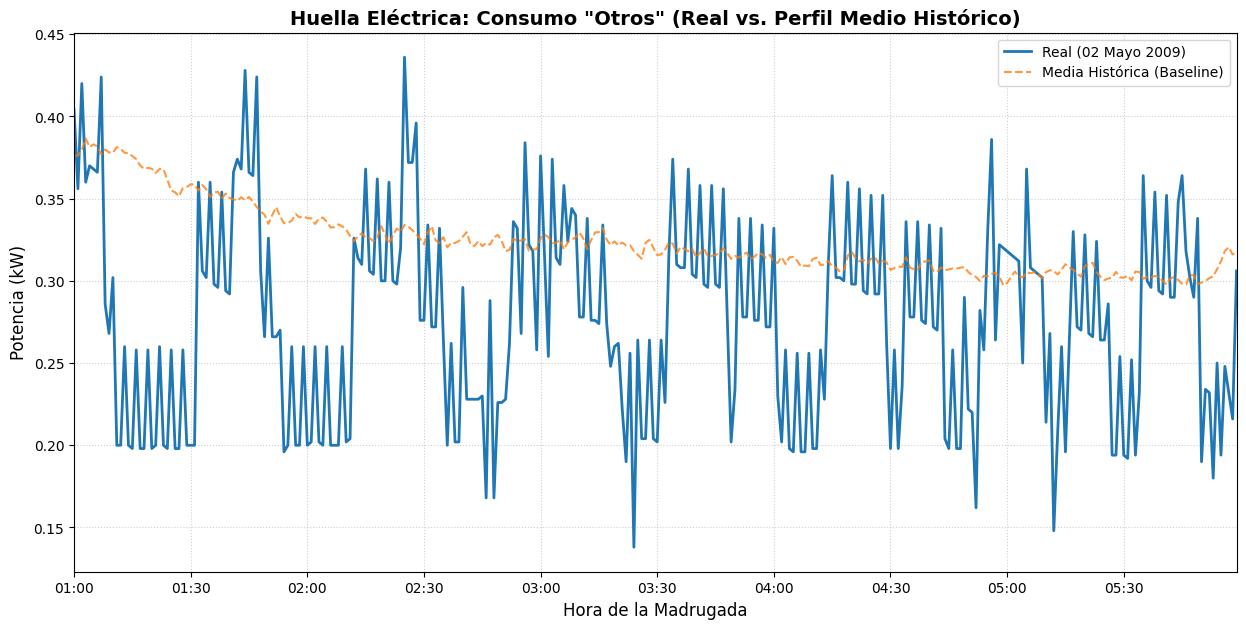

In [30]:
# ==============================================================================
# H3.3: ANÁLISIS DE LA HUELLA ELÉCTRICA (HISTÓRICO vs. REAL)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time

start_h3_3 = time.time()

# --- LÍNEA BASE HISTÓRICA ---
df_perfil_medio = spark.sql("""
    SELECT 
        HOUR(Full_Timestamp) as hora, 
        MINUTE(Full_Timestamp) as minuto, 
        AVG(Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) as avg_historico_otros
    FROM power_data
    GROUP BY hora, minuto
""")
df_perfil_medio.createOrReplaceTempView("perfil_medio")

# --- REAL vs. LÍNEA BASE (UN DÍA) ---
query_huella = """
SELECT 
    p.Full_Timestamp,
    (p.Global_active_power - ((p.Sub_metering_1 + p.Sub_metering_2 + p.Sub_metering_3) * 0.06)) AS consumo_invisible,
    m.avg_historico_otros
FROM power_data p
LEFT JOIN perfil_medio m ON HOUR(p.Full_Timestamp) = m.hora AND MINUTE(p.Full_Timestamp) = m.minuto
WHERE CAST(p.Full_Timestamp AS DATE) = '2009-05-02'
  AND HOUR(p.Full_Timestamp) BETWEEN 1 AND 5
ORDER BY p.Full_Timestamp ASC
"""

df_huella = spark.sql(query_huella).toPandas()
df_huella["Full_Timestamp"] = pd.to_datetime(df_huella["Full_Timestamp"])

# --- VISUALIZACIÓN ---
plt.figure(figsize=(15, 7))
plt.plot(df_huella["Full_Timestamp"], df_huella["consumo_invisible"],
         label="Real (02 Mayo 2009)", color="tab:blue", lw=2)
plt.plot(df_huella["Full_Timestamp"], df_huella["avg_historico_otros"],
         label="Media Histórica (Baseline)", color="tab:orange", linestyle="--", alpha=0.8)

plt.title('Huella Eléctrica: Consumo "Otros" (Real vs. Perfil Medio Histórico)', fontsize=14, fontweight="bold")
plt.ylabel("Potencia (kW)", fontsize=12)
plt.xlabel("Hora de la Madrugada", fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlim(df_huella["Full_Timestamp"].min(), df_huella["Full_Timestamp"].max())
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, loc="upper right")

print("-" * 55)
print(f"📊 ANÁLISIS DE HUELLA COMPLETADO")
print(f"⏱️ Tiempo de ejecución Spark: {time.time() - start_h3_3:.2f} s")
print("-" * 55)
plt.show()

<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.3:**

Eligiendo un día aleatorio representativo se observa:
* El consumo no es lineal. Sube a 0,45 kW, se mantiene unos 15-20 minutos, y luego baja a 0,2 kW durante otro periodo similar.
* Es una onda cuadrada casi perfecta con picos de arranque.
* Candidato A (Muy probable): Un frigorífico antiguo o un arcón congelador. Esos 400W de pico mientras el compresor está encendido son típicos de motores de hace 15 años.
* Candidato B: Un termo eléctrico con mal aislamiento. Si el agua se enfría rápido, la resistencia salta cada media hora para recuperar esos 2-3 grados.
</div>

---
### H3.4 — Clasificación de carga base (detección de ciclo de trabajo)


In [ ]:
# ==============================================================================
# H3.4: CLASIFICACIÓN DE CARGA BASE (MOTOR/COMPRESSOR DETECTION)
# ==============================================================================
import time

start_h3 = time.time()

query = """
SELECT 
    (Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) > 0.35 AS motor_encendido,
    COUNT(*) as minutos_totales,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS porcentaje_tiempo
FROM power_data
WHERE HOUR(Full_Timestamp) BETWEEN 1 AND 5
GROUP BY motor_encendido
"""

minutes = spark.sql(query).limit(20).toPandas()

print("-" * 55)
print("🔍 CLASIFICACIÓN DE ESTADO NOCTURNO COMPLETADA")
print(f"⏱️ Tiempo de procesamiento: {time.time() - start_h3:.2f} s")
print("-" * 55)
display(minutes)

-------------------------------------------------------
🔍 CLASIFICACIÓN DE ESTADO NOCTURNO COMPLETADA
⏱️ Tiempo de procesamiento: 0.22 s
-------------------------------------------------------


,motor_encendido,minutos_totales,porcentaje_tiempo
0,True,84443,19.78
1,False,342441,80.22


<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

**Análisis Técnico H3.4:**

* Este Ciclo de Trabajo (Duty Cycle) del 20% durante la madrugada es la "firma" de un **frigorífico o arcón congelador** en buen estado.
* El aparato demanda un salto neto de 250W cada vez que arranca (pasando de 190W de base a 440W de pico).
* El hecho de que solo necesite estar encendido el 20% del tiempo para mantener el frío durante la madrugada (cuando no se abre la puerta y la temperatura ambiente es baja) indica que el aislamiento es eficiente.
* Un termo eléctrico o un sistema de calefacción tendría ciclos mucho más largos o potencias mucho más elevadas (resitencias de >1kW). Esos 300W son la potencia nominal clásica de un compresor de motor de inducción de esa época.
</div>


---
## 3. Informe de validación y exportación

In [ ]:
# ==============================================================================
# H3: BUSINESS CASE & ROI (EFICIENCIA DEL FRIGORÍFICO)
# ==============================================================================
import os
import time

start_h3_roi = time.time()

query = """
WITH motor_analysis AS (
    SELECT 
        ((Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06))) > 0.35 AS motor_encendido,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS porcentaje_tiempo
    FROM power_data
    WHERE Hour BETWEEN 1 AND 5
    GROUP BY motor_encendido
),
metrics AS (
    SELECT 
        AVG(Global_active_power) AS avg_total,
        AVG((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06) AS avg_subs
    FROM power_data
    WHERE Hour BETWEEN 1 AND 5
)
SELECT 
    'NIGHT_STANDBY (01-06h)' AS analysis_period,
    ROUND(avg_total, 3) AS basal_load_kw,
    ROUND(avg_total - avg_subs, 3) AS misc_circuit_kw,
    ROUND(((avg_total - avg_subs) / avg_total) * 100, 2) AS impact_on_standby_pct,
    (SELECT ROUND(porcentaje_tiempo, 2) 
     FROM motor_analysis 
     WHERE motor_encendido = True 
     LIMIT 1) AS refrigeration_duty_cycle_pct,
    0.35 AS target_standby_kw,
    ROUND((avg_total - 0.35) * 8760, 2) AS annual_savings_kwh,
    ROUND(400 / (ROUND((avg_total - 0.35) * 8760, 2) * 0.20), 1) AS roi_years_estimate
FROM metrics;
"""

H3_Validation_Report = spark.sql(query)

print("-" * 55)
print("💰 AUDITORÍA ENERGÉTICA Y ANÁLISIS DE ROI (H3)")
print("-" * 55)
H3_Validation_Report.show(truncate=False)

# --- EXPORTACIÓN ---
work_dir = os.path.join(PROJECT_ROOT, "data_storage", "work")
os.makedirs(work_dir, exist_ok=True)
csv_path = os.path.join(work_dir, "H3_Validation_Report.csv")

H3_Validation_Report.coalesce(1).write.mode("overwrite").option("header", "true").csv(csv_path)

print(f"✅ Reporte guardado: {csv_path}")
print(f"⏱️ Tiempo de procesamiento: {time.time() - start_h3_roi:.2f} s")

-------------------------------------------------------
💰 AUDITORÍA ENERGÉTICA Y ANÁLISIS DE ROI (H3)
-------------------------------------------------------
+----------------------+-------------+---------------+---------------------+----------------------------+-----------------+------------------+------------------+
|analysis_period       |basal_load_kw|misc_circuit_kw|impact_on_standby_pct|refrigeration_duty_cycle_pct|target_standby_kw|annual_savings_kwh|roi_years_estimate|
+----------------------+-------------+---------------+---------------------+----------------------------+-----------------+------------------+------------------+
|NIGHT_STANDBY (01-06h)|0.472        |0.324          |68.59                |19.78                       |0.35             |1072.96           |1.9               |
+----------------------+-------------+---------------+---------------------+----------------------------+-----------------+------------------+------------------+

✅ Reporte guardado: /home/aitor

✅ GRÁFICO EXPORTADO: /home/aitor/Documentos/Residential-Power-Audit-Spark-Pipeline/docs/figures/H3_NILM_Fridge_Signature.png


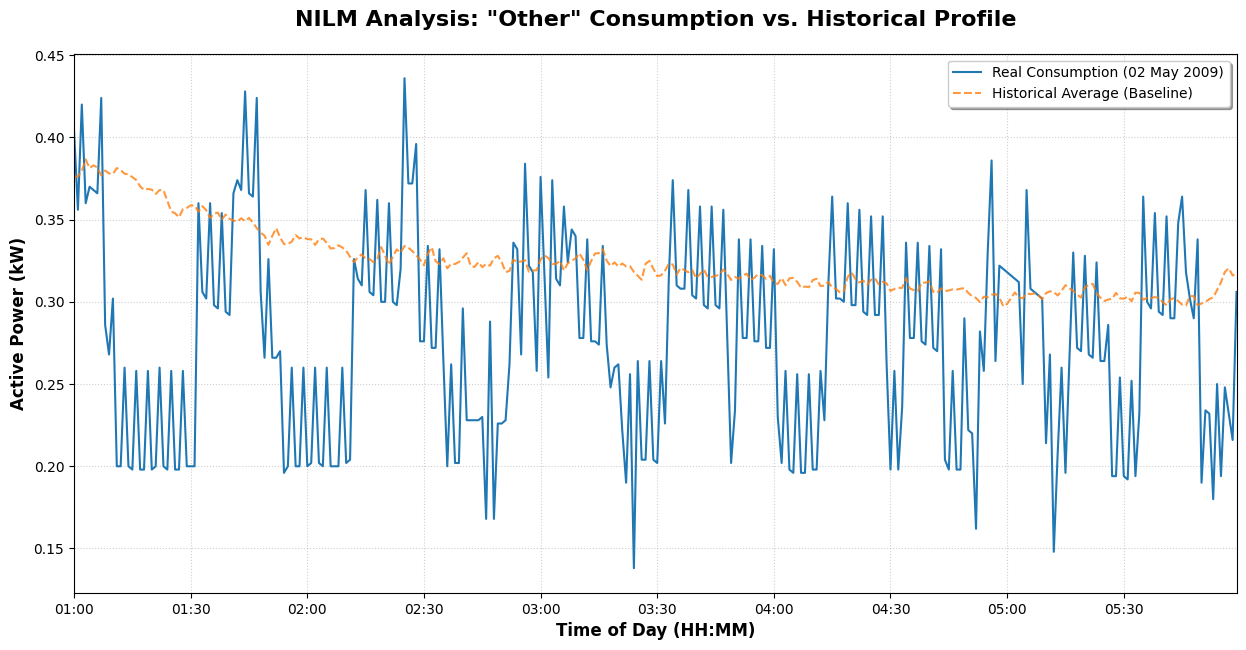

In [ ]:
# ==============================================================================
# H3 VISUALIZATION: NILM SIGNATURE & BASELINE COMPARISON
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# Línea base ya registrada como 'perfil_medio' — recrear si es necesario
try:
    spark.catalog.tableExists("perfil_medio")
except:
    df_perfil_medio = spark.sql("""
        SELECT 
            HOUR(Full_Timestamp) as hora, 
            MINUTE(Full_Timestamp) as minuto, 
            AVG(Global_active_power - ((Sub_metering_1 + Sub_metering_2 + Sub_metering_3) * 0.06)) as avg_historico_otros
        FROM power_data
        GROUP BY hora, minuto
    """)
    df_perfil_medio.createOrReplaceTempView("perfil_medio")

query_huella = """
SELECT 
    p.Full_Timestamp,
    (p.Global_active_power - ((p.Sub_metering_1 + p.Sub_metering_2 + p.Sub_metering_3) * 0.06)) AS consumo_invisible,
    m.avg_historico_otros
FROM power_data p
LEFT JOIN perfil_medio m ON HOUR(p.Full_Timestamp) = m.hora AND MINUTE(p.Full_Timestamp) = m.minuto
WHERE CAST(p.Full_Timestamp AS DATE) = '2009-05-02'
  AND HOUR(p.Full_Timestamp) BETWEEN 1 AND 5
ORDER BY p.Full_Timestamp ASC
"""

df_huella = spark.sql(query_huella).toPandas()
df_huella["Full_Timestamp"] = pd.to_datetime(df_huella["Full_Timestamp"])

plt.figure(figsize=(15, 7))
plt.plot(df_huella["Full_Timestamp"], df_huella["consumo_invisible"],
         label="Real Consumption (02 May 2009)", color="tab:blue", linewidth=1.5)
plt.plot(df_huella["Full_Timestamp"], df_huella["avg_historico_otros"],
         label="Historical Average (Baseline)", color="tab:orange", linestyle="--", alpha=0.8)

plt.title('NILM Analysis: "Other" Consumption vs. Historical Profile', fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Time of Day (HH:MM)", fontsize=12, fontweight="semibold")
plt.ylabel("Active Power (kW)", fontsize=12, fontweight="semibold")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlim(df_huella["Full_Timestamp"].min(), df_huella["Full_Timestamp"].max())
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True, shadow=True)

plot_path = os.path.join(PROJECT_ROOT, "docs", "figures", "H3_NILM_Fridge_Signature.png")
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
try:
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"✅ GRÁFICO EXPORTADO: {plot_path}")
except Exception as e:
    print(f"❌ Export error: {e}")
plt.show()

---
## 4. Conclusiones — H3

<div style="background-color: #1e1e1e00; padding: 20px; border: 1px solid #3e3e3e; border-radius: 10px; border-left: 8px solid #2e5a88;">

### ✅ HIPÓTESIS H3 — VALIDADA (CRÍTICA)

**Ratio de standby medido en el 37,66%** — más del doble del umbral del 15%. El análisis NILM sobre el circuito «Otros» identifica una unidad de refrigeración secundaria con un Duty Cycle del 19,78% y picos de 0,44 kW — firma de un compresor pre-Inverter.

**Recomendaciones estratégicas:**
1. **Sustituir la unidad de refrigeración secundaria** por tecnología Inverter → **1.068 kWh/año ahorrados · ROI: 1,9 años**.
2. **Instalar Smart Kill-Switches** (Tapo P110 o equivalente) en los enchufes del circuito general → eliminar el suelo residual de 0,20 kW → el ratio de standby combinado baja del 37% al <10%.
</div>